# Split training ablation experiment

Compares graph recovery between models that are identical in every way — same data, same initial weights, same hyperparameters — differing only in whether they use the sequence-split approximation during EM/Viterbi training.

Pairs compared:
- `cscg_se` vs `cscg_se_split_base` (soft-evidence models)
- `cscg_he` vs `cscg_he_split_base` (hard-evidence models)

The `*_split_base` variants inherit from the base (non-opt) models, so the **only** algorithmic difference is the boundary approximation: each sequence segment restarts forward/backward messages from the prior `pi` rather than from the true forward message at the segment boundary.

## Imports

In [ ]:
import jax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'font.size': 14})

from cscg import cscg_se
from cscg import cscg_se_split_em
from cscg import cscg_he
from cscg import cscg_he_split_em
from cscg import utils

print(f'JAX devices: {jax.device_count()}')

JAX devices: 8


## Grid world

/tmp/ipykernel_2328615/2524606469.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_grid = plt.cm.get_cmap('tab10', 9)


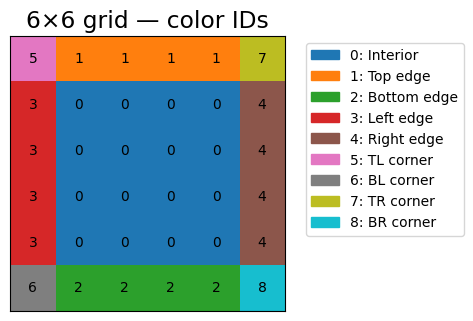

In [38]:
n = 6  # grid size

def build_grid(n):
    """Build an n×n color-ID grid."""
    grid = np.zeros((n, n), dtype=int)
    grid[0, 1:-1] = 1   # top
    grid[-1, 1:-1] = 2  # bottom
    grid[1:-1, 0] = 3   # left
    grid[1:-1, -1] = 4  # right
    grid[0, 0] = 5    # top-left
    grid[-1, 0] = 6   # bottom-left
    grid[0, -1] = 7   # top-right
    grid[-1, -1] = 8  # bottom-right
    return grid

grid = build_grid(n)

obs_names = [
    'Interior', 'Top edge', 'Bottom edge', 'Left edge', 'Right edge',
    'TL corner', 'BL corner', 'TR corner', 'BR corner',
]

fig, ax = plt.subplots(figsize=(5, 5))
cmap_grid = plt.cm.get_cmap('tab10', 9)
im = ax.imshow(grid, cmap=cmap_grid, vmin=-0.5, vmax=8.5)
for r in range(n):
    for c in range(n):
        ax.text(c, r, str(grid[r, c]), ha='center', va='center', fontsize=10, color='k')
ax.set_title(f'{n}×{n} grid — color IDs')
ax.set_xticks([])
ax.set_yticks([])
patches = [mpatches.Patch(color=cmap_grid(i / 8), label=f'{i}: {obs_names[i]}') for i in range(9)]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## Generate training data

In [39]:
def generate_random_walk(grid, length, seed=0):
    """Random walk on grid. Returns (actions, observations, positions).

    Actions: 0=N, 1=E, 2=S, 3=W.
    action[t] is the action taken at step t, causing the transition to step t+1.
    The final action is a dummy (0).
    """
    rng = np.random.default_rng(seed)
    n = grid.shape[0]
    deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # N, E, S, W

    r, c = n // 2, n // 2  # start at center
    observations = np.zeros(length, dtype=int)
    actions = np.zeros(length, dtype=int)
    positions = np.zeros((length, 2), dtype=int)

    observations[0] = grid[r, c]
    positions[0] = (r, c)

    for t in range(length - 1):
        a = int(rng.integers(0, 4))
        dr, dc = deltas[a]
        nr, nc = r + dr, c + dc
        if 0 <= nr < n and 0 <= nc < n:
            r, c = nr, nc
        actions[t] = a
        observations[t + 1] = grid[r, c]
        positions[t + 1] = (r, c)

    return actions, observations, positions

length = 120000
a, x, pos_walk = generate_random_walk(grid, length, seed=42)

print(f'Sequence length: {length:,}')
print(f'Unique observations: {np.unique(x)}')
visited = set(map(tuple, pos_walk))
print(f'Grid cells visited: {len(visited)} / {n*n}')

Sequence length: 120,000
Unique observations: [0 1 2 3 4 5 6 7 8]
Grid cells visited: 36 / 36


## Model configuration

All four models share the same:
- `n_clones` (clone allocation)
- `seed=0` → identical initial counts matrix
- `pseudocount`
- Training sequence `x_train`, `a_train`

The sequence length `T` is trimmed to be divisible by `n_devices × num_splits` so both split and non-split models (which only require divisibility by `n_devices`) can use the same data.

In [ ]:
n_obs = int(grid.max()) + 1
n_clones = 3 * np.array([(grid == i).sum() for i in range(n_obs)], dtype=int)
print('n_clones:')
for i, (name, nc) in enumerate(zip(obs_names, n_clones)):
    print(f'  obs {i} ({name}): {nc}')
print(f'Total states: {n_clones.sum()} (grid cells: {n*n})')

num_splits = 2
n_devices = jax.device_count()
T = (length // (n_devices * num_splits)) * (n_devices * num_splits)
x_train, a_train = x[:T], a[:T]
pos_train = pos_walk[:T]
print(f'\nTraining sequence length: {T:,} (devices={n_devices}, num_splits={num_splits})')

pseudocount = 5e-4
SEED = 0
N_EM_ITER = 200
N_VIT_ITER = 10

n_clones:
  obs 0 (Interior): 48
  obs 1 (Top edge): 12
  obs 2 (Bottom edge): 12
  obs 3 (Left edge): 12
  obs 4 (Right edge): 12
  obs 5 (TL corner): 3
  obs 6 (BL corner): 3
  obs 7 (TR corner): 3
  obs 8 (BR corner): 3
Total states: 108 (grid cells: 36)

Training sequence length: 120,000 (devices=8, num_splits=2)


## Instantiate models

All four models are created with `seed=0`, giving them the same random initial counts matrix. We assert this below.

In [ ]:
model_se = cscg_se.CSCG(
    n_clones=n_clones, pseudocount=pseudocount, n_actions=4,
    seed=SEED, batched=True, use_bfloat16=False,
)
model_se_split = cscg_se_split_em.CSCG(
    n_clones=n_clones, pseudocount=pseudocount, n_actions=4,
    seed=SEED, batched=True, use_bfloat16=False, num_splits=num_splits,
)
model_he = cscg_he.CSCG(
    n_clones=n_clones, pseudocount=pseudocount, n_actions=4,
    seed=SEED, batched=True, use_bfloat16=False,
)
model_he_split = cscg_he_split_em.CSCG(
    n_clones=n_clones, pseudocount=pseudocount, n_actions=4,
    seed=SEED, batched=True, use_bfloat16=False, num_splits=num_splits,
)

# Verify identical initial counts matrices (same seed → same random init)
assert np.allclose(model_se.counts_matrix, model_se_split.counts_matrix), \
    'SE models have different initial counts!'
assert np.allclose(model_he.counts_matrix, model_he_split.counts_matrix), \
    'HE models have different initial counts!'

models = [
    ('SE (no split)',    model_se),
    ('SE (split)',       model_se_split),
    ('HE (no split)',    model_he),
    ('HE (split)',       model_he_split),
]

for label, m in models:
    print(f'{label}: implementation={m.implementation}, states={m.num_states}')

SE (no split): implementation=se, states=108
SE (split): implementation=se_split_base_2, states=108
HE (no split): implementation=he, states=108
HE (split): implementation=he_split_base_2, states=108


## Train all models

Each model runs EM training followed by Viterbi training using the exact same sequence.

In [ ]:
convergence = {}

for label, m in models:
    print(f'\n=== Training {label} ===')
    conv_em = m.learn_em_transition(
        observations=x_train, actions=a_train, n_iter=N_EM_ITER, term_early=True,
    )
    conv_vit = m.learn_viterbi_transition(
        observations=x_train, actions=a_train, n_iter=N_VIT_ITER,
    )
    convergence[label] = (conv_em, conv_vit)
    print(f'  EM iters: {len(conv_em)}, final bps: {conv_em[-1]:.4f}')
    print(f'  Viterbi iters: {len(conv_vit)}, final bps: {conv_vit[-1]:.4f}')


=== Training SE (no split) ===


 50%|█████     | 100/200 [00:45<00:45,  2.21it/s, train_bps=0.0006101923]
0it [00:00, ?it/s]


  EM iters: 101, final bps: 0.0006

=== Training SE (split) ===


 52%|█████▎    | 105/200 [00:34<00:31,  3.04it/s, train_bps=0.00093129603]
0it [00:00, ?it/s]


  EM iters: 106, final bps: 0.0009

=== Training HE (no split) ===


 50%|████▉     | 99/200 [01:13<01:15,  1.34it/s, train_bps=0.00061019656]
0it [00:00, ?it/s]


  EM iters: 100, final bps: 0.0006

=== Training HE (split) ===


 52%|█████▏    | 103/200 [00:48<00:45,  2.14it/s, train_bps=0.0009313171] 
0it [00:00, ?it/s]

  EM iters: 104, final bps: 0.0009


## Convergence curves

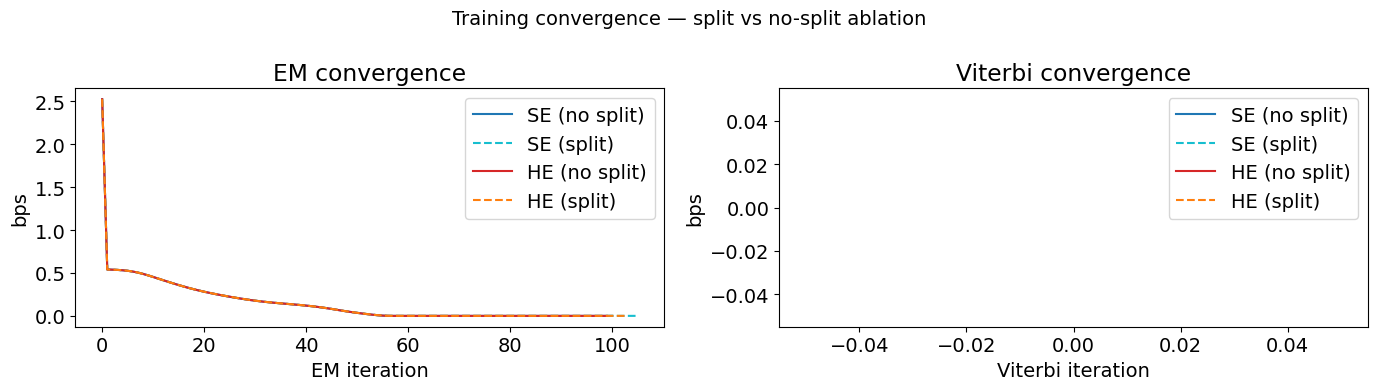

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['tab:blue', 'tab:cyan', 'tab:red', 'tab:orange']
linestyles = ['-', '--', '-', '--']

for (label, _), color, ls in zip(models, colors, linestyles):
    conv_em, conv_vit = convergence[label]
    axes[0].plot(conv_em, label=label, color=color, linestyle=ls)
    axes[1].plot(conv_vit, label=label, color=color, linestyle=ls)

axes[0].set_xlabel('EM iteration')
axes[0].set_ylabel('bps')
axes[0].set_title('EM convergence')
axes[0].legend()

axes[1].set_xlabel('Viterbi iteration')
axes[1].set_ylabel('bps')
axes[1].set_title('Viterbi convergence')
axes[1].legend()

plt.suptitle('Training convergence — split vs no-split ablation', fontsize=14)
plt.tight_layout()
plt.show()

## Decode and build position maps

In [44]:
def decode_and_build_pos(model):
    states = np.array(model.decode(observations=x_train, actions=a_train)[1])
    state_pos_counts = {}
    for t, s in enumerate(states):
        rc = (int(pos_train[t, 0]), int(pos_train[t, 1]))
        if s not in state_pos_counts:
            state_pos_counts[s] = {}
        state_pos_counts[s][rc] = state_pos_counts[s].get(rc, 0) + 1
    state_to_pos = {s: max(cnt, key=cnt.get) for s, cnt in state_pos_counts.items()}
    unique_states = np.unique(states)
    pos_graph = {
        i: (state_to_pos[s][1], -state_to_pos[s][0])
        for i, s in enumerate(unique_states)
    }
    return states, pos_graph

results = {}
for label, m in models:
    states, pos_graph = decode_and_build_pos(m)
    results[label] = (states, pos_graph)
    print(f'{label}: {len(np.unique(states))} unique decoded states (grid cells: {n*n})')

SE (no split): 70 unique decoded states (grid cells: 36)
SE (split): 70 unique decoded states (grid cells: 36)
HE (no split): 70 unique decoded states (grid cells: 36)
HE (split): 70 unique decoded states (grid cells: 36)


## Compare recovered graphs

2×2 grid: rows = SE / HE, columns = no-split / split.

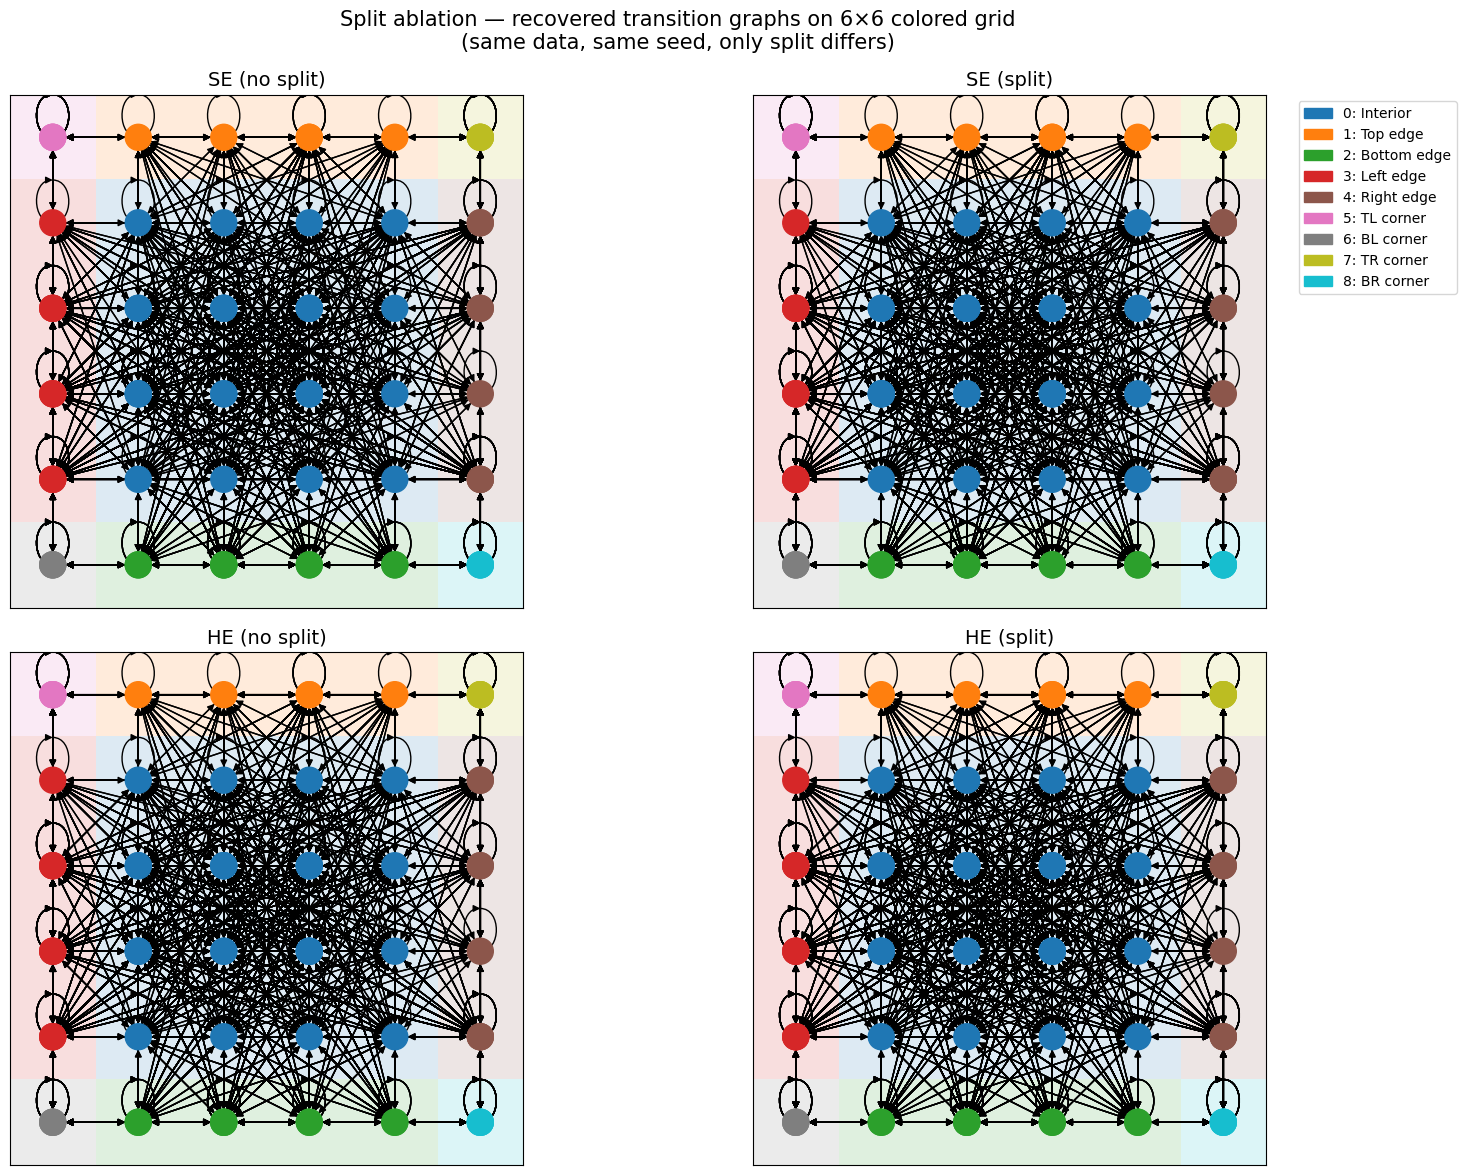

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

layout = [
    [('SE (no split)', model_se),    ('SE (split)', model_se_split)],
    [('HE (no split)', model_he),    ('HE (split)', model_he_split)],
]

for row, row_models in enumerate(layout):
    for col, (label, m) in enumerate(row_models):
        ax = axes[row, col]
        states, pos_graph = results[label]

        ax.imshow(
            grid, cmap=cmap_grid, vmin=-0.5, vmax=8.5, alpha=0.15,
            extent=[-0.5, n - 0.5, -(n - 0.5), 0.5],
        )
        utils.plot_graph(
            m.counts_matrix,
            states,
            n_clones,
            x_train.max(),
            ax=ax,
            pos=pos_graph,
            node_size=350,
            threshold=0.0,
            cmap='tab10',
        )
        ax.set_xlim(-0.5, n - 0.5)
        ax.set_ylim(-(n - 0.5), 0.5)
        ax.set_title(label, fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')

patches = [mpatches.Patch(color=cmap_grid(i / 8), label=f'{i}: {obs_names[i]}') for i in range(9)]
axes[0, 1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.suptitle(
    f'Split ablation — recovered transition graphs on {n}×{n} colored grid\n'
    f'(same data, same seed, only split differs)',
    fontsize=15,
)
plt.tight_layout()
plt.show()

## Summary statistics

In [46]:
print(f'Ground truth: {n*n} grid cells, {n_clones.sum()} total clones')
print()
print(f'{"Model":<20} {"Decoded states":>15} {"EM iters":>10} {"EM bps":>10} {"Vit iters":>10} {"Vit bps":>10}')
print('-' * 80)
for label, m in models:
    states, _ = results[label]
    conv_em, conv_vit = convergence[label]
    print(
        f'{label:<20} {len(np.unique(states)):>15} '
        f'{len(conv_em):>10} {conv_em[-1]:>10.4f} '
        f'{len(conv_vit):>10} {conv_vit[-1]:>10.4f}'
    )

Ground truth: 36 grid cells, 108 total clones

Model                 Decoded states   EM iters     EM bps  Vit iters    Vit bps
--------------------------------------------------------------------------------


IndexError: list index out of range